In [ ]:
%pip install -q scikit-learn==1.5.2
%pip install -q tsururu==1.0.1
%pip install chronos-forecasting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 94.3 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.2/75.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.6/889.6 kB 16.8 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 6.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00:00:0100:01m
   ━━━━━━━━━━

In [ ]:
import logging

logger = logging.getLogger(__name__)
import sys

c_handler = logging.StreamHandler(sys.stdout)
logger.addHandler(c_handler)
logging.basicConfig(level=logging.INFO, force=True)

import random
import warnings
from datetime import datetime
from typing import Any

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import torch
import torch.nn as nn
from chronos import BaseChronosPipeline
from plotly.subplots import make_subplots
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import (
    MinMaxScaler,
    PowerTransformer,
    RobustScaler,
    StandardScaler,
)
from torch.nn import Module
from tqdm.notebook import tqdm

from tsururu.dataset import Pipeline, TSDataset
from tsururu.model_training.trainer import DLTrainer, MLTrainer
from tsururu.model_training.validator import KFoldCrossValidator, HoldOutValidator
from tsururu.models.boost import CatBoost
from tsururu.strategies import RecursiveStrategy

warnings.filterwarnings("ignore")

In [ ]:
def choose_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using GPU")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using MPS")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
DEVICE = choose_device()
HORIZON = 36
HISTORY = 52

Using GPU


# Dataset

Возьмем данные Tourism Monthly Dataset (https://zenodo.org/records/4656096).

In [ ]:
def convert_tsf_to_dataframe(
    full_file_path_and_name: str,
    replace_missing_vals_with: Any = "NaN",
    value_column_name: str = "series_value",
) -> tuple[pd.DataFrame, str, int, str, str]:
    col_names = []
    col_types = []
    all_data = {}
    all_series = []
    frequency = None
    forecast_horizon = None
    contain_missing_values = None
    contain_equal_length = None
    data_started = False

    with open(full_file_path_and_name, "r", encoding="cp1252") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            if line.startswith("@"):
                if line.startswith("@data"):
                    data_started = True
                    for col in col_names:
                        all_data[col] = []
                else:
                    parts = line.split(" ")
                    if line.startswith("@attribute"):
                        col_names.append(parts[1])
                        col_types.append(parts[2])
                    elif line.startswith("@frequency"):
                        frequency = parts[1]
                    elif line.startswith("@horizon"):
                        forecast_horizon = int(parts[1])
                    elif line.startswith("@missing"):
                        contain_missing_values = parts[1].lower() in (
                            "y",
                            "yes",
                            "t",
                            "true",
                            "on",
                            "1",
                        )
                    elif line.startswith("@equallength"):
                        contain_equal_length = parts[1].lower() in (
                            "y",
                            "yes",
                            "t",
                            "true",
                            "on",
                            "1",
                        )
            elif not line.startswith("#") and data_started:
                parts = line.split(":")
                series_vals = parts[-1].split(",")
                numeric_series = [
                    replace_missing_vals_with if val == "?" else float(val) for val in series_vals
                ]
                all_series.append(pd.Series(numeric_series).array)
                for i in range(len(col_names)):
                    if col_types[i] == "numeric":
                        all_data[col_names[i]].append(int(parts[i]))
                    elif col_types[i] == "string":
                        all_data[col_names[i]].append(parts[i])
                    elif col_types[i] == "date":
                        all_data[col_names[i]].append(
                            datetime.strptime(parts[i], "%Y-%m-%d %H-%M-%S")
                        )

    all_data[value_column_name] = all_series
    loaded_data = pd.DataFrame(all_data)
    return loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length


def date_to_daterange(x: pd.Series, freq: str) -> pd.Series:
    return pd.Series(pd.date_range(start=x.iloc[0], periods=len(x), freq=freq))


def convert_tsf_to_multivariate_or_standard_format(
    tsf_data_path: str,
    target_column: str = "series_value",
    date_from_column: str = "start_timestamp",
    id_column: str = "series_name",
    format: str = "multivariate",
) -> pd.DataFrame:

    FREQ_MAP = {
        "monthly": "MS",
        "10_minutes": "10min",
        "half_hourly": "30min",
        "minutely": "1min",
        "daily": "D",
        "weekly": "7D",
        "yearly": "YS",
        "quarterly": "QS",
        "hourly": "H",
    }

    tsf_df, freq = convert_tsf_to_dataframe(tsf_data_path)[:2]
    tsf_df = tsf_df.explode(target_column)
    tsf_df["date"] = (
        tsf_df.groupby(id_column, sort=False)[date_from_column]
        .apply(lambda x: date_to_daterange(x, FREQ_MAP[freq]))
        .values
    )
    tsf_df = tsf_df.drop(columns=date_from_column)
    tsf_df = tsf_df.rename(columns={id_column: "id", target_column: "value"}).reset_index(
        drop=True
    )
    ids2num = dict(zip(tsf_df["id"].unique(), np.arange(tsf_df["id"].nunique())))
    tsf_df["id"] = tsf_df["id"].map(ids2num)

    if format == "standard":
        return tsf_df
    return pd.pivot_table(tsf_df, values="value", index="date", columns="id")

In [ ]:
df = convert_tsf_to_multivariate_or_standard_format('tourism_monthly_dataset.tsf', format="standard")
df["value"] = df["value"].astype("float")
df.head()

,id,value,date
0,0,1149.8700,1979-01-01
1,0,1053.8002,1979-02-01
2,0,1388.8798,1979-03-01
3,0,1783.3702,1979-04-01
4,0,1921.0252,1979-05-01


In [ ]:
fig = go.Figure()
for i in df["id"].unique():
    fig.add_trace(
        go.Scatter(x=df[df["id"] == i]["date"], y=df[df["id"] == i]["value"], name=str(i))
    )
fig.update_layout(title="Tourism Monthly Dataset", xaxis_title="Date", yaxis_title="Value")
fig.show()

# Preprocessing

Методы предобработки временных рядов помогают стабилизировать данные, удалить тренды и сезонность, и привести значения к сопоставимому диапазону.

__Давайте на примере одного ряда посмотрим, как они работают.__

In [ ]:
random_series = 33  
random_series = df[df["id"] == random_series]

train_size = len(random_series) - HORIZON
train_split_date = np.sort(random_series["date"])[train_size]

train_data = random_series[random_series["date"] < train_split_date]
test_data = random_series[random_series["date"] >= train_split_date]

`Логарифмирование / Box-Cox / Yeo-Johnson`

Эти методы используются, чтобы стабилизировать дисперсию. Особенно полезны при наличии мультипликативных эффектов.

- Логарифмирование и Box-Cox подходит только для положительных значений.
- Yeo-Johnson может применяться при отрицательных значениях.

__Box-Cox__:

$$ y' = \frac{y^\lambda - 1}{\lambda} \text{, если } \lambda \neq 0$$
$$ y' = \log(y) \text{, если } \lambda = 0$$

__Yeo-Johnson__:
$$ y' = \begin{cases}
\frac{((y + 1)^\lambda - 1)}{\lambda} \text{, если } y \geq 0 \text{ и } \lambda \neq 0\\
\log(y + 1) \text{, если } y \geq 0 \text{ и } \lambda = 0\\
\frac{-((-y + 1)^{2 - \lambda} - 1)}{2 - \lambda} \text{, если } y < 0 \text{ и } \lambda \neq 2\\
-\log(-y + 1) \text{, если } y < 0 \text{ и } \lambda = 2
\end{cases}$$

На практике чаще используют простое логарифмирование, так как с более сложными методами возникают с подбором параметров.

Обратите так же внимание, что при использовании подобных трансформаций обратное преобразование точечного прогноза не даёт среднее значение прогностического распределения. На практике это значение обычно соответствует медиане распределения и иногда это необходимо учитывать и корректировать.

__Обратное преобразование для Box-Cox, при котором мы учитываем смещение (bias adjusted)__:

$$ y = \begin{cases}
(\lambda y' + 1)^{\frac{1}{\lambda}} \left[1 + \dfrac{\sigma^2_h(1-\lambda)}{2(\lambda y' + 1)^2} \right] \text{, если } \lambda \neq 0\\
\exp(y') \left[ 1 + \dfrac{\sigma^2_h}{2} \right] \text{, если } \lambda = 0
\end{cases}$$

__Пример того, насколько могут различаться скорректированные и некорректированные обратные преобразования__:

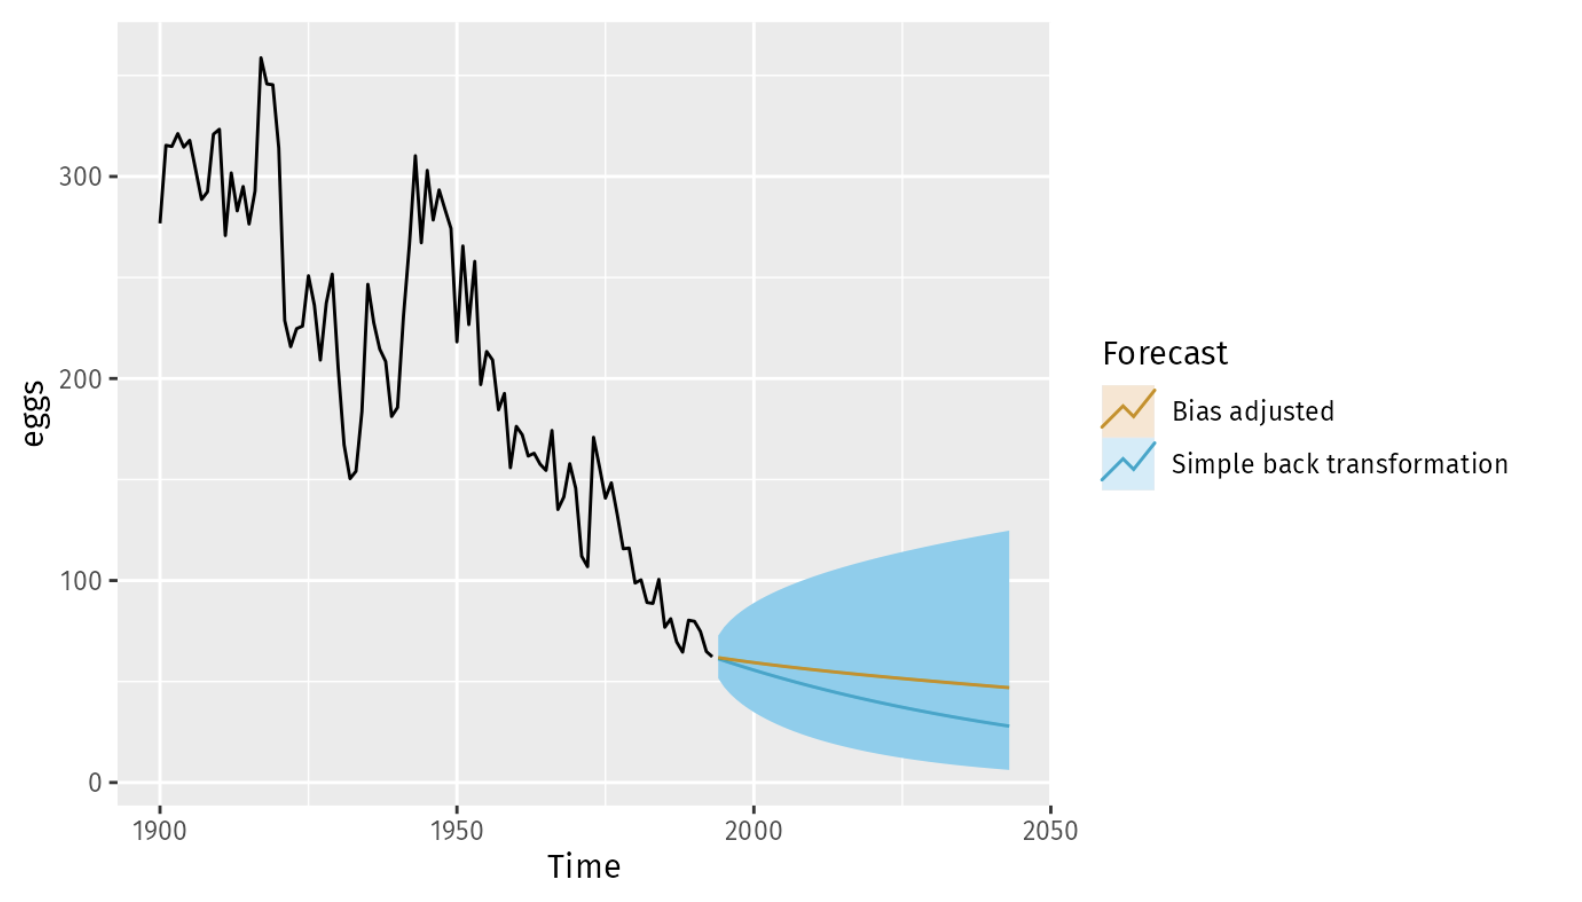

Оба метода есть в sklearn: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html

Однако обратите внимание, что обратное преобразование там смещенное.

In [ ]:
# Logarithmic transformation
train_data["log_value"] = np.log1p(train_data["value"])
test_data["log_value"] = np.log1p(test_data["value"])

# Box-Cox transformation
pt = PowerTransformer(method="box-cox")
train_data["boxcox_value"] = pt.fit_transform(train_data[["value"]])
test_data["boxcox_value"] = pt.transform(test_data[["value"]])

# Yeo-Johnson transformation
pt = PowerTransformer(method="yeo-johnson")
train_data["yeojohnson_value"] = pt.fit_transform(train_data[["value"]])
test_data["yeojohnson_value"] = pt.transform(test_data[["value"]])

In [ ]:
fig = make_subplots(cols=2, subplot_titles=("Оригинальный ряд", "Преобразования"))
for dataset, name in zip([train_data, test_data], ["train", "test"]):
    fig.add_trace(
        go.Scatter(x=dataset["date"], y=dataset["value"], name=name),
        row=1, col=1
    )
for transformer in ["log_value", "boxcox_value", "yeojohnson_value"]:
    for dataset, prefix in zip([train_data, test_data], ["train", "test"]):
        fig.add_trace(
            go.Scatter(x=dataset["date"], y=dataset[transformer], name=f"{prefix}_{transformer}"),
            row=1, col=2
        )
fig.update_layout(
    title="Преобразования временного ряда",
    xaxis_title="Date",
    yaxis_title="Value",
    showlegend=True
)

fig.show()

`Сезонное и обычное дифференцирование`

Сезонное дифференцирование помогает убрать влияние сезонности, а обычное дифференцирование — тренд.
- Сезонное дифференцирование: $y_t - y_{t-s}$ или $y_t / y_{t-s}$, где $s$ — длина сезона
- Обычное дифференцирование: $y_t - y_{t-1}$ или $y_t / y_{t-1}$

In [ ]:
# Seasonal Difference
train_data["seasonal_diff_delta"] = train_data["value"].diff(12)
test_data["seasonal_diff_delta"] = test_data["value"].diff(12)
train_data["seasonal_diff_ratio"] = train_data["value"] / train_data["value"].shift(12)
test_data["seasonal_diff_ratio"] = test_data["value"] / test_data["value"].shift(12)

# Difference
train_data["diff_delta"] = train_data["value"].diff(1)
test_data["diff_delta"] = test_data["value"].diff(1)
train_data["diff_ratio"] = train_data["value"] / train_data["value"].shift(1)
test_data["diff_ratio"] = test_data["value"] / test_data["value"].shift(1)

In [ ]:
fig = make_subplots(cols=2, subplot_titles=("Оригинальный ряд", "Разности"))
for dataset, name in zip([train_data, test_data], ["train", "test"]):
    fig.add_trace(
        go.Scatter(x=dataset["date"], y=dataset["value"], name=name),
        row=1, col=1
    )
for transformer in ["seasonal_diff_delta", "diff_delta"]:
    for dataset, prefix in zip([train_data, test_data], ["train", "test"]):
        fig.add_trace(
            go.Scatter(x=dataset["date"], y=dataset[transformer], name=f"{prefix}_{transformer}"),
            row=1, col=2
        )
fig.update_layout(
    title="Разности временного ряда",
    xaxis_title="Date",
    yaxis_title="Value",
    showlegend=True
)
fig.show()

In [ ]:
fig = make_subplots(cols=2, subplot_titles=("Оригинальный ряд", "Разности"))
for dataset, name in zip([train_data, test_data], ["train", "test"]):
    fig.add_trace(
        go.Scatter(x=dataset["date"], y=dataset["value"], name=name),
        row=1, col=1
    )
for transformer in ["seasonal_diff_ratio", "diff_ratio"]:
    for dataset, prefix in zip([train_data, test_data], ["train", "test"]):
        fig.add_trace(
            go.Scatter(x=dataset["date"], y=dataset[transformer], name=f"{prefix}_{transformer}"),
            row=1, col=2
        )
fig.update_layout(
    title="Разности временного ряда",
    xaxis_title="Date",
    yaxis_title="Value",
    showlegend=True
)
fig.show()

`StandartScaler, MinMaxScaler, RobustScaler`

Эти методы помогают привести данные к сопоставимому диапазону, что может быть критично для некоторых моделей.

- StandartScaler: $$y' = \frac{y - \mu}{\sigma}$$ где $\mu$ и $\sigma$ — среднее и стандартное отклонение соответственно.
  
- MinMaxScaler: $$y' = \frac{y - min(y)}{max(y) - min(y)}$$
  
- RobustScaler: $$y' = \frac{y - Q1}{Q3 - Q1}$$ где Q1 и Q3 — первый и третий квартили соответственно.

In [ ]:
# Standard Scaler
scaler = StandardScaler()
train_data["scaled_value"] = scaler.fit_transform(train_data[["value"]])
test_data["scaled_value"] = scaler.transform(test_data[["value"]])

# MinMax Scaler
scaler = MinMaxScaler()
train_data["minmax_scaled_value"] = scaler.fit_transform(train_data[["value"]])
test_data["minmax_scaled_value"] = scaler.transform(test_data[["value"]])

# Robust Scaler
scaler = RobustScaler()
train_data["robust_scaled_value"] = scaler.fit_transform(train_data[["value"]])
test_data["robust_scaled_value"] = scaler.transform(test_data[["value"]])

In [ ]:
fig = make_subplots(cols=2, subplot_titles=("Оригинальный ряд", "Ряды после скейлингов"))
for dataset, name in zip([train_data, test_data], ["train", "test"]):
    fig.add_trace(
        go.Scatter(x=dataset["date"], y=dataset["value"], name=name),
        row=1, col=1
    )
for transformer in [
    "scaled_value",
    "minmax_scaled_value",
    "robust_scaled_value",
]:
    for dataset, prefix in zip([train_data, test_data], ["train", "test"]):
        fig.add_trace(
            go.Scatter(x=dataset["date"], y=dataset[transformer], name=f"{prefix}_{transformer}"),
            row=1, col=2
        )
fig.update_layout(
    title="Скейлинги временного ряда",
    xaxis_title="Date",
    yaxis_title="Value",
    showlegend=True
)
fig.show()

### Multivariate Time Series: using Tsururu

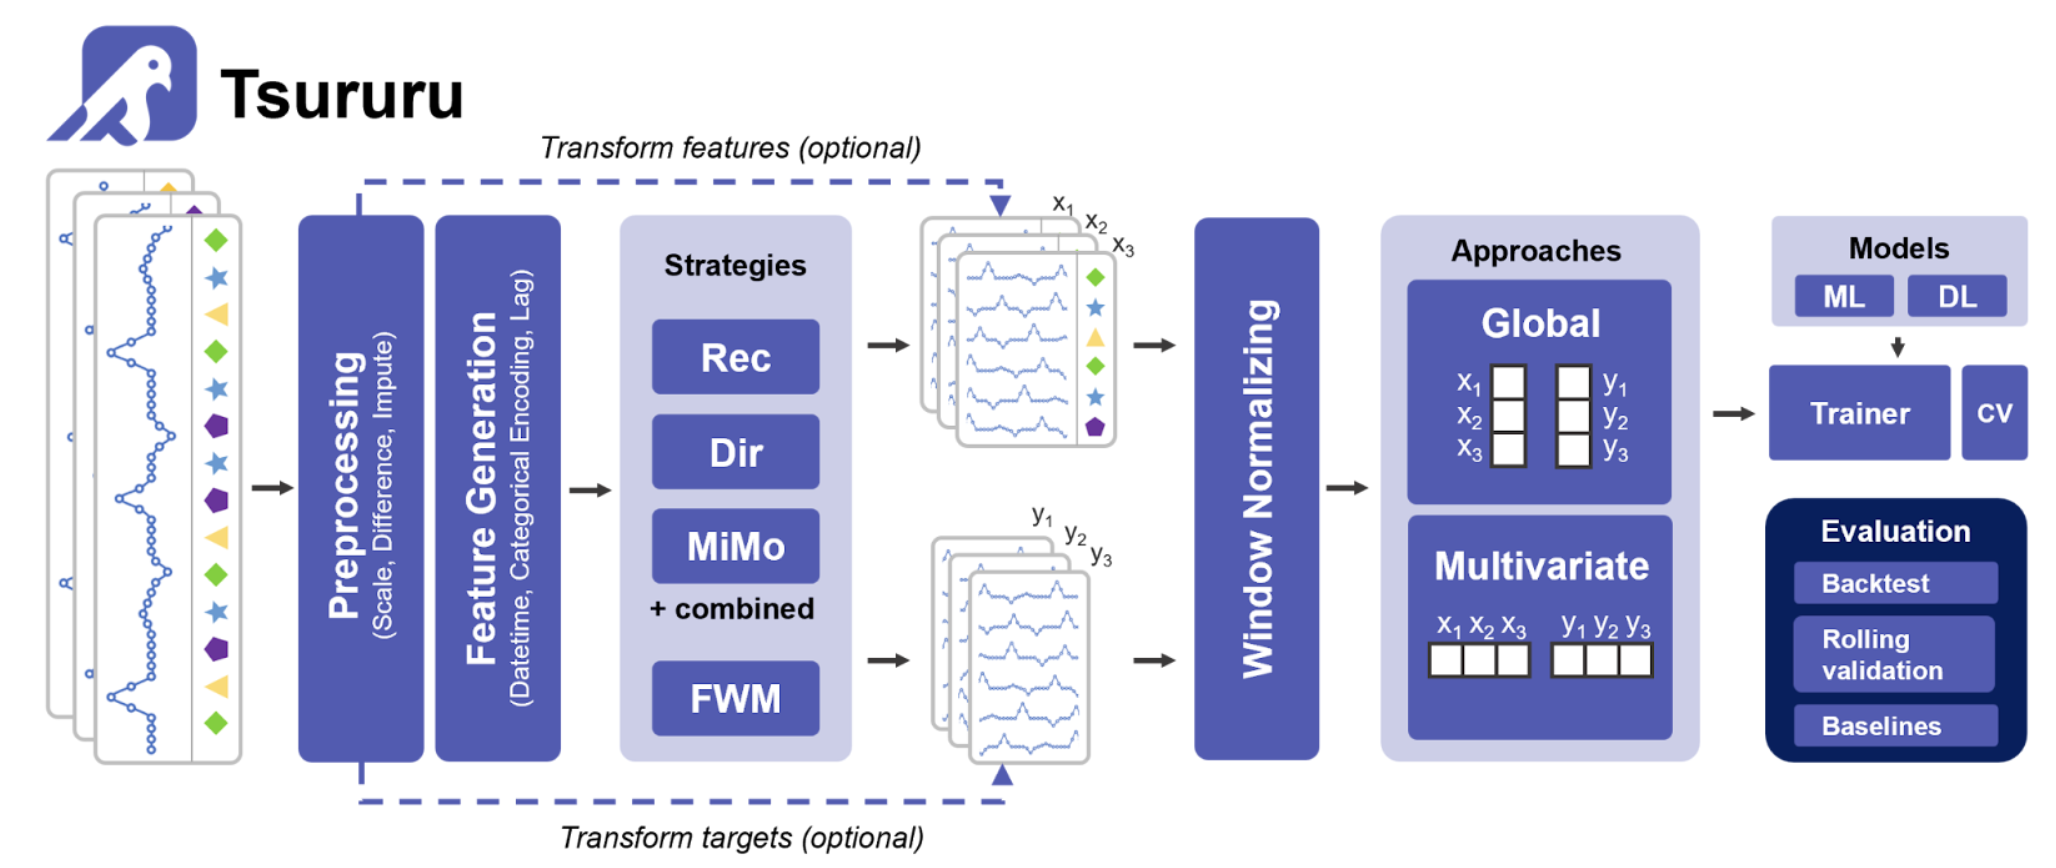

В библиотеке Tsururu реализованы несколько методов предобработки данных, которые позволяют это сделать:
- StandardScalerTransformer
- DifferenceNormalizer
- LastKnownNormalizer

Первые два совпадают с тем, что мы смотрели выше. Просто добавляется возможность указать, __надо ли считать разные ряды за независимые сегменты (например, для целевой переменной) или нет (например, для признаков дат). Также можно указать, нужно ли трансформировать признаки и таргеты или только что-то одно из них.__ `LastKnownNormalizer` работает в окне: мы вычитаем из текущего значения в окне последнее известное значение (или делим на него). Это помогает нам бороться с локальными артефактами.

Если интересно, как это устроено внутри библиотеки, то есть очень подробный туториал о том, как работает пайплайн предобработки и генерации признаков: https://github.com/sb-ai-lab/tsururu/blob/main/examples/Tutorial_3_Transformers_and_Pipeline.ipynb

In [ ]:
def analyze_predictions(train_df, test_targets, current_pred, last_points=50):
    train_df = train_df.rename(columns={
        "unique_id": "id",
        "y": "value",
        "ds": "date",
    })

    num_ids = 10
    last_points = 50

    colors = [
        "blue", "green", "orange", "purple", "brown",
        "cyan", "magenta", "olive", "teal", "grey",
    ]

    seed_everything()
    random_ids = np.random.choice(test_targets["id"].unique(), num_ids, replace=False)

    random_mae = mean_absolute_error(
        test_targets.loc[test_targets["id"].isin(random_ids), "value"],
        current_pred.loc[current_pred["id"].isin(random_ids), "value"],
    )
    print(f"random {num_ids} mae: {random_mae}")

    fig = go.Figure()

    for i, _id in enumerate(random_ids):
        color = colors[i % len(colors)]

        train_series = train_df[train_df["id"] == _id]
        train_series = train_series.iloc[-min(len(train_series), last_points):]
        train_values = train_series["value"].tolist()
        n_train = len(train_values)

        test_targets_series = test_targets[test_targets["id"] == _id]
        target_values = test_targets_series["value"].tolist()
        n_test = len(target_values)

        preds_series = current_pred[current_pred["id"] == _id]
        preds_values = preds_series["value"].tolist()

        x_train = np.arange(-n_train, 0)
        x_test = np.arange(0, n_test)
        x_pred = np.arange(0, n_test)

        fig.add_trace(go.Scatter(
            x=x_train,
            y=train_values,
            mode="lines",
            name=f"id {_id} train",
            line=dict(color=color)
        ))

        fig.add_trace(go.Scatter(
            x=x_test,
            y=target_values,
            mode="lines",
            name=f"id {_id} true",
            line=dict(color=color)
        ))

        fig.add_trace(go.Scatter(
            x=x_pred,
            y=preds_values,
            mode="lines",
            name=f"id {_id} pred",
            line=dict(color=color, dash="dash")
        ))

    fig.add_shape(dict(
        type="line",
        x0=0,
        y0=0,
        x1=0,
        y1=1,
        xref="x",
        yref="paper",
        line=dict(color="red", width=4)
    ))

    fig.update_layout(
        title="Predictions vs True Values",
        xaxis_title="Date",
        yaxis_title="Values"
    )

    fig.show()

__Будем использовать неклассическую Global Rec-MIMO стратегию и CatBoost в качестве базовой модели.__

Global-стратегия позволит нам работать с невыровненными рядами.

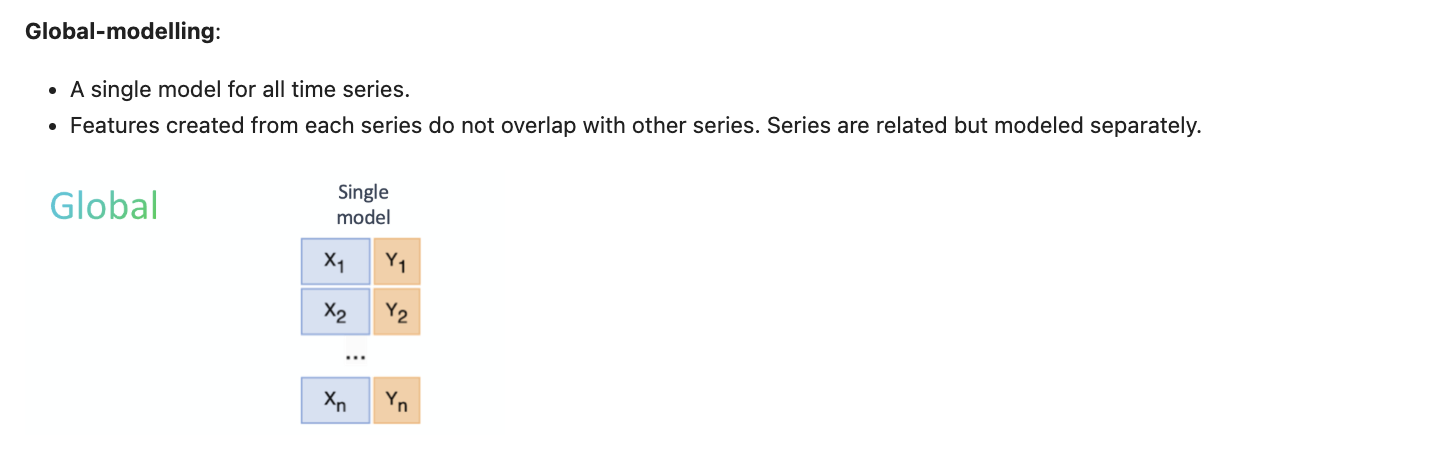

А Rec-MIMO позволит нам получить что-то среднее между быстрой и привычной для классического анализа временных рядов авторегрессионной стратегией и более сложной и привычной для DL multioutput стратегией.

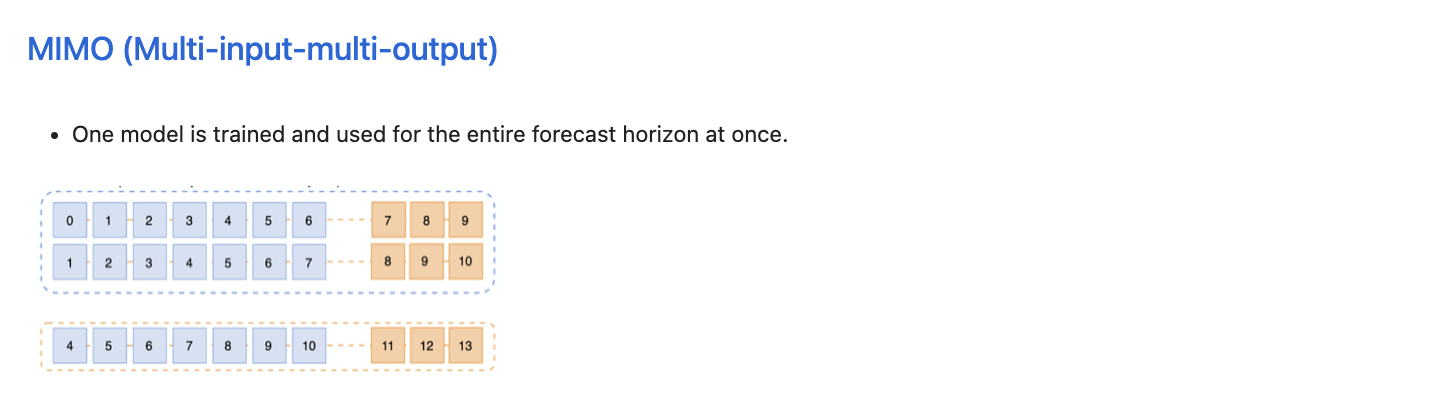

In [ ]:
train_df = []
test_df = []
test_targets = []

for current_id in df["id"].unique():
    current_df = df[df["id"] == current_id]
    train_df.append(current_df.iloc[:-HORIZON])
    test_df.append(current_df.iloc[-HORIZON - HISTORY : -HORIZON])
    test_targets.append(current_df.iloc[-HORIZON:])

train_df = pd.concat(train_df)
test_df = pd.concat(test_df)
test_targets = pd.concat(test_targets)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Test targets shape: {test_targets.shape}")

print(f"Number of series in train set: {train_df['id'].nunique()}")
print(f"Number of series in test set: {test_df['id'].nunique()}")
print(f"Number of series in test targets set: {test_targets['id'].nunique()}")

Train shape: (96104, 3)
Test shape: (19032, 3)
Test targets shape: (13176, 3)
Number of series in train set: 366
Number of series in test set: 366
Number of series in test targets set: 366


In [ ]:
dataset_params = {
    "target": {"columns": ["value"]},
    "date": {"columns": ["date"]},
    "id": {"columns": ["id"]},
}


train_dataset = TSDataset(
    data=train_df,
    columns_params=dataset_params,
)
test_dataset = TSDataset(
    data=test_df,
    columns_params=dataset_params,
)

INFO:tsururu.dataset.dataset:freq: Month; period: 1.0
                It seems that the data is not regular. Please, check the data and the frequency info.                
                For multivariate regime it is critical to have regular data.
                For global regime each regular part of time series will be processed as separate time series.           
                
INFO:tsururu.dataset.dataset:freq: Month; period: 1.0
                It seems that the data is not regular. Please, check the data and the frequency info.                
                For multivariate regime it is critical to have regular data.
                For global regime each regular part of time series will be processed as separate time series.           
                


In [ ]:
# Определим сетку параметров для разных видов препроцессинга
transformers = ["standard_scaler", "difference_normalizer", "last_known_normalizer"]

# Для экономии времени (и так как в ряде есть околонулевые значения) оставим только delta
regimes = ["none", "delta"]

In [ ]:
results = {}
preds = {}

for transformer in tqdm(transformers):
    for regime in tqdm(regimes):
        print(transformer, regime)
        if transformer == "standard_scaler" and regime != "none":
            continue
        if (transformer == "difference_normalizer" or transformer == "last_known_normalizer") and regime == "none":
            continue

        pipeline_easy_params = {
            "target_lags": HISTORY,
            "date_lags": 1,
            "target_normalizer": transformer,
            "target_normalizer_regime": regime,
            "normalizer_regime": regime,
        }

        # Pipeline отвечает за трансформации временного ряда на всех этапах прогноза от препроцессинга
        # и генерации признаков до Window_normalizing (нормализации на уровне наблюдений для ML моделей)
        # multivariate=False означает, что используем global-modelling (в нашей задаче единственный возможный вариант, т. к. ряды не выровнены)

        # При использовании easy_setup трансформации делаются и на признаки, и на таргеты
        pipeline = Pipeline.easy_setup(
            dataset_params, pipeline_easy_params, multivariate=False
        )
        # Trainer отвечает за обучение модели с использованием inner loop валидации
        trainer = MLTrainer(model=CatBoost, model_params={"task_type": "GPU"}, validator=KFoldCrossValidator)
        # Стратегия отвечает за то, как мы генерируем выборку для предсказания на несколько точек вперед (подробнее на лекции)
        strategy = RecursiveStrategy(horizon=HORIZON, model_horizon=4, history=HISTORY, pipeline=pipeline, trainer=trainer)

        fit_time, _ = strategy.fit(train_dataset)
        forecast_time, current_pred = strategy.predict(test_dataset)

        # Будем использовать метрику MAE (Кстати, какие могут быть проблемы при использовании этой метрики?)
        results[f"{transformer}_{regime}_mae"] = mean_absolute_error(
            test_targets["value"].values, current_pred["value"].values
        )
        preds[f"{transformer}_{regime}_preds"] = current_pred

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

standard_scaler none


INFO3:tsururu.models.boost:0:	learn: 1.9543580	test: 1.9447708	best: 1.9447708 (0)	total: 15.9ms	remaining: 15.8s
DEBUG:tsururu.models.boost:100:	learn: 1.0975255	test: 1.0908101	best: 1.0908101 (100)	total: 1.12s	remaining: 9.96s
DEBUG:tsururu.models.boost:200:	learn: 1.0237935	test: 1.0231986	best: 1.0231986 (200)	total: 2.08s	remaining: 8.27s
DEBUG:tsururu.models.boost:300:	learn: 0.9898752	test: 0.9946632	best: 0.9946632 (300)	total: 3.02s	remaining: 7.02s
DEBUG:tsururu.models.boost:400:	learn: 0.9672396	test: 0.9781852	best: 0.9781852 (400)	total: 3.99s	remaining: 5.96s
DEBUG:tsururu.models.boost:500:	learn: 0.9502471	test: 0.9669795	best: 0.9669795 (500)	total: 4.95s	remaining: 4.93s
DEBUG:tsururu.models.boost:600:	learn: 0.9368064	test: 0.9588049	best: 0.9588049 (600)	total: 5.91s	remaining: 3.92s
DEBUG:tsururu.models.boost:700:	learn: 0.9254178	test: 0.9525273	best: 0.9525273 (700)	total: 6.86s	remaining: 2.93s
DEBUG:tsururu.models.boost:800:	learn: 0.9152562	test: 0.9472033	be

standard_scaler delta


...

difference_normalizer none
difference_normalizer delta


INFO3:tsururu.models.boost:0:	learn: 17276.5898477	test: 16665.1947781	best: 16665.1947781 (0)	total: 15ms	remaining: 15s
DEBUG:tsururu.models.boost:100:	learn: 9873.7355830	test: 10210.1031679	best: 10210.1031679 (100)	total: 1.1s	remaining: 9.8s
DEBUG:tsururu.models.boost:200:	learn: 8191.8502622	test: 9266.3682381	best: 9266.3682381 (200)	total: 2.04s	remaining: 8.12s
DEBUG:tsururu.models.boost:300:	learn: 7277.1233784	test: 8911.7495928	best: 8911.7495928 (300)	total: 3.01s	remaining: 6.98s
DEBUG:tsururu.models.boost:400:	learn: 6635.7313458	test: 8709.2213037	best: 8709.2213037 (400)	total: 3.99s	remaining: 5.96s
DEBUG:tsururu.models.boost:500:	learn: 6140.6111472	test: 8582.2603250	best: 8582.2603250 (500)	total: 4.96s	remaining: 4.94s
DEBUG:tsururu.models.boost:600:	learn: 5746.0885312	test: 8486.7579383	best: 8486.7579383 (600)	total: 5.95s	remaining: 3.95s
DEBUG:tsururu.models.boost:700:	learn: 5404.2787287	test: 8407.4183987	best: 8407.4183987 (700)	total: 6.84s	remaining: 2.

  0%|          | 0/2 [00:00<?, ?it/s]

last_known_normalizer none
last_known_normalizer delta


INFO3:tsururu.models.boost:0:	learn: 27883.5256012	test: 28252.0140809	best: 28252.0140809 (0)	total: 14.7ms	remaining: 14.7s
DEBUG:tsururu.models.boost:100:	learn: 14388.4754333	test: 15287.6448255	best: 15287.6448255 (100)	total: 1.11s	remaining: 9.93s
DEBUG:tsururu.models.boost:200:	learn: 12115.8041759	test: 13833.9114745	best: 13833.9114745 (200)	total: 2.07s	remaining: 8.24s
DEBUG:tsururu.models.boost:300:	learn: 10781.7506416	test: 13297.8778095	best: 13297.8778095 (300)	total: 3.01s	remaining: 7s
DEBUG:tsururu.models.boost:400:	learn: 9723.2634118	test: 12870.1670929	best: 12870.1670929 (400)	total: 3.96s	remaining: 5.91s
DEBUG:tsururu.models.boost:500:	learn: 8933.1876967	test: 12632.3657279	best: 12632.3657279 (500)	total: 4.9s	remaining: 4.88s
DEBUG:tsururu.models.boost:600:	learn: 8320.8069337	test: 12460.2585061	best: 12460.2585061 (600)	total: 5.87s	remaining: 3.9s
DEBUG:tsururu.models.boost:700:	learn: 7792.7516437	test: 12304.0293477	best: 12304.0293477 (700)	total: 6.7

In [ ]:
res_df = pd.DataFrame.from_dict(results, orient="index", columns=["MAE"])
res_df

,MAE
standard_scaler_none_mae,4234.514121
difference_normalizer_delta_mae,3763.318270
last_known_normalizer_delta_mae,4041.837231


__Нарисуем предсказания для лучшего кейса.__

In [ ]:
analyze_predictions(train_df, test_targets, preds[f"difference_normalizer_delta_preds"], last_points=50)

random 10 mae: 1236.88733466504


# DL Supervised: DLinear

__Давайте попробуем перейти от ML к DL и посмотреть, как работают DLinear.__

`DLinear` — это простая и быстрая модель, которая выделяет тренд на основе AveragePooling, а затем на компонентах тренда и остатков применяет nn.Linear и собирает всё обратно.

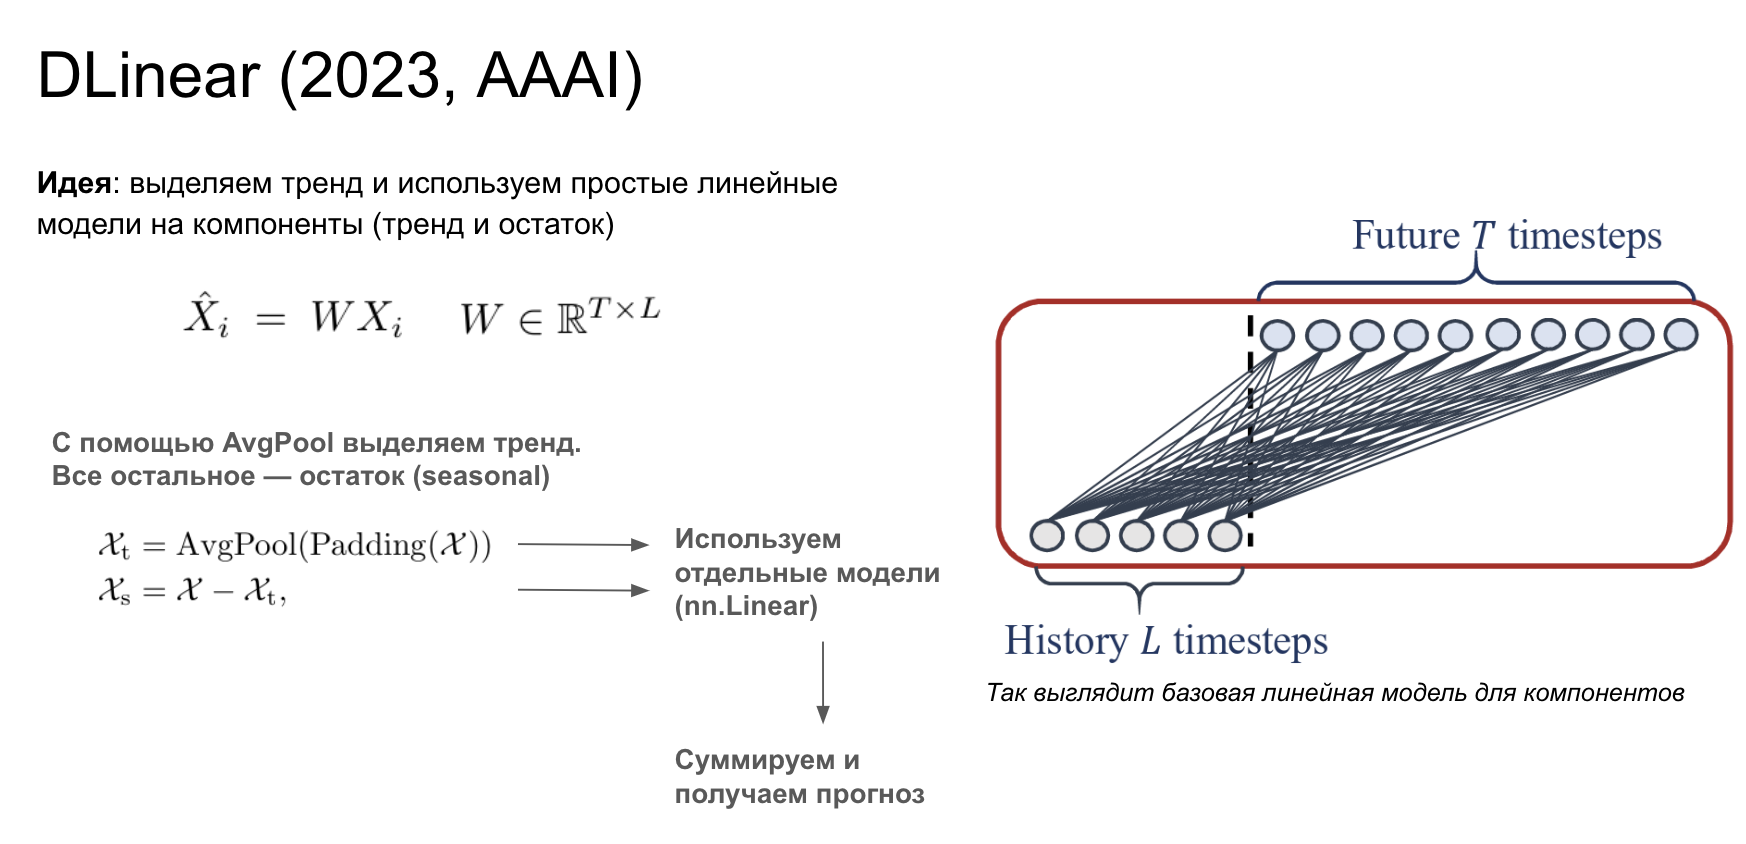

In [ ]:
class moving_avg(Module):
    """Moving average block to highlight the trend of time series.

    Args:
        kernel_size: size of the kernel.
        stride: stride for the moving average.

    """

    def __init__(self, kernel_size: int, stride: int):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x: "torch.Tensor") -> "torch.Tensor":
        """Forward pass for computing the moving average.

        Args:
            x: input tensor.

        Returns:
            tensor with the moving average applied.

        """
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)

        # apply moving average (among the time series dimension)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)

        return x


class series_decomp(Module):
    """Series decomposition block.

    Args:
        kernel_size: size of the kernel for the moving average.

    """

    def __init__(self, kernel_size: int):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x: "torch.Tensor") -> tuple["torch.Tensor", "torch.Tensor"]:
        """Forward pass for decomposing the series into trend and remainder.

        Args:
            x: input tensor.

        Returns:
            tuple of tensors (remainder, trend).

        """
        moving_mean = self.moving_avg(x)
        res = x - moving_mean

        return res, moving_mean


class DLinear_NN(Module):
    """DLInear model from the paper https://arxiv.org/pdf/2205.13504.pdf.

    Args:
        - seq_len: int, the length of the input sequence.
        - pred_len: int, the length of the output sequence.
        - moving_avg: int, the size of the moving average window.

    """

    def __init__(
        self,
        seq_len: int,
        pred_len: int,
        moving_avg: int = 25,
    ):
        super(DLinear_NN, self).__init__()
        # Params from model_params
        self.seq_len = seq_len
        self.pred_len = pred_len

        # Decomposition
        self.decompsition = series_decomp(moving_avg)

        # Linear layers
        self.Linear_Seasonal = nn.Linear(self.seq_len, self.pred_len)
        self.Linear_Trend = nn.Linear(self.seq_len, self.pred_len)

        # Linear layers initialization
        self.Linear_Seasonal.weight = nn.Parameter(
            (1 / self.seq_len) * torch.ones([self.pred_len, self.seq_len])
        )
        self.Linear_Trend.weight = nn.Parameter(
            (1 / self.seq_len) * torch.ones([self.pred_len, self.seq_len])
        )

    def forward(self, x: "torch.Tensor") -> "torch.Tensor":
        """Forward pass of the model.

        Args:
            x: input tensor of shape (batch_size, seq_len, num_features).

        Returns:
            Encoded tensor of shape (batch_size, pred_len, num_features).

        """
        # Делаем декомпозицию временного ряда на тренд и остаток (seasonal)
        seasonal_init, trend_init = self.decompsition(x)

        # Транспонируем тензоры, чтобы они были в формате (batch_size, num_features, seq_len)
        seasonal_init, trend_init = seasonal_init.permute(0, 2, 1), trend_init.permute(0, 2, 1)

        # Применяем линейные слои к тренду и остаткам
        seasonal_output = self.Linear_Seasonal(seasonal_init)
        trend_output = self.Linear_Trend(trend_init)

        # Складываем выходы линейных слоев
        x = seasonal_output + trend_output

        # Транспонируем обратно в формат (batch_size, seq_len, num_features)
        x = x.permute(0, 2, 1)

        return x[:, -self.pred_len :, :]

Выделим явно валидационную выборку.

In [ ]:
train_df = []
val_df = []
test_df = []
test_targets = []
for current_id in df["id"].unique():
    current_df = df[df["id"] == current_id]
    train_df.append(current_df.iloc[:-2 * HORIZON])
    val_df.append(current_df.iloc[-2 * HORIZON - HISTORY : -HORIZON])
    test_df.append(current_df.iloc[-HORIZON - HISTORY:-HORIZON])
    test_targets.append(current_df.iloc[-HORIZON:])
train_df = pd.concat(train_df)
val_df = pd.concat(val_df)
test_df = pd.concat(test_df)
test_targets = pd.concat(test_targets)

print(f"Train shape: {train_df.shape}")
print(f"Val shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Test targets shape: {test_targets.shape}")

print(f"Number of series in train set: {train_df['id'].nunique()}")
print(f"Number of series in val set: {val_df['id'].nunique()}")
print(f"Number of series in test set: {test_df['id'].nunique()}")
print(f"Number of series in test targets set: {test_targets['id'].nunique()}")

Train shape: (82928, 3)
Val shape: (32175, 3)
Test shape: (19032, 3)
Test targets shape: (13176, 3)
Number of series in train set: 366
Number of series in val set: 366
Number of series in test set: 366
Number of series in test targets set: 366


In [ ]:
seed_everything()
dataset_params = {
    "target": {
        "columns": ["value"],
        "type": "continuous",
    },
    "date": {
        "columns": ["date"],
        "type": "datetime",
    },
    "id": {
        "columns": ["id"],
        "type": "categorical",
    }
}

train_dataset = TSDataset(
    data=train_df,
    columns_params=dataset_params,
    print_freq_period_info=True,
)
val_dataset = TSDataset(
    data=val_df,
    columns_params=dataset_params,
    print_freq_period_info=False,
)
test_dataset = TSDataset(
    data=test_df,
    columns_params=dataset_params,
    print_freq_period_info=False,
)

INFO:tsururu.dataset.dataset:freq: Month; period: 1.0
                It seems that the data is not regular. Please, check the data and the frequency info.                
                For multivariate regime it is critical to have regular data.
                For global regime each regular part of time series will be processed as separate time series.           
                
                It seems that the data is not regular. Please, check the data and the frequency info.                
                For multivariate regime it is critical to have regular data.
                For global regime each regular part of time series will be processed as separate time series.           
                
                It seems that the data is not regular. Please, check the data and the frequency info.                
                For multivariate regime it is critical to have regular data.
                For global regime each regular part of time series will be processed 

In [ ]:
pipeline_params = {
    "target": {
        "columns": ["value"],
        "features": {
            "DifferenceNormalizer": {
                    "regime": "delta",
                    "transform_target": True,  # Видим параметры, которые отвечают за раздельное применение
                    "transform_features": True,  # трансформеров к признакам и таргетам
                },
            "MissingValuesImputer": {  # После DifferenceNormalizer у нас неизбежно появляются NaN в данных (в первом значении каждого сегмента)
                "constant_value": 0,  # Заполним нулями
                "transform_target": True,
                "transform_features": True,
            },
            "StandardScalerTransformer": {  # И выровним значения рядов прежде чем подавать в DL модель
                "transform_target": True,
                "transform_features": True,
                "agg_by_id": True,
            },
            "LagTransformer": {"lags": HISTORY},
        },
    }
}

In [ ]:
pipeline = Pipeline.from_dict(pipeline_params, multivariate=False)

validation = HoldOutValidator
validation_params = {
    "validation_data": val_dataset
}

trainer_params = {
    "device": DEVICE,
    "num_workers": 4,
    "best_by_metric": True,
    "save_to_dir": False,
    "batch_size": 128,
    "n_epochs": 5,
    "early_stopping_patience": 2,
}


# Configure the model and validation parameters
trainer = DLTrainer(
    model=DLinear_NN,
    model_params={},
    validator=validation,
    validation_params=validation_params,
    **trainer_params,
)

strategy = RecursiveStrategy(horizon=HORIZON, model_horizon=4, history=HISTORY, pipeline=pipeline, trainer=trainer)

fit_time, _ = strategy.fit(train_dataset)
forecast_time, current_pred = strategy.predict(test_dataset)

INFO:tsururu.model_training.trainer:length of train dataset: 62834
INFO:tsururu.model_training.trainer:length of val dataset: 12045
INFO:tsururu.model_training.trainer:Epoch 1/5, cost time: 33.20s
INFO:tsururu.model_training.trainer:train loss: 0.6801
INFO:tsururu.model_training.trainer:Validation, Loss: 1.7615, Metric: -1.7615
INFO:tsururu.model_training.trainer:val loss: 1.7615, val metric: -1.7615
INFO:tsururu.model_training.trainer:Epoch 2/5, cost time: 33.37s
INFO:tsururu.model_training.trainer:train loss: 0.5797
INFO:tsururu.model_training.trainer:Validation, Loss: 1.7575, Metric: -1.7575
INFO:tsururu.model_training.trainer:val loss: 1.7575, val metric: -1.7575
INFO:tsururu.model_training.trainer:Epoch 3/5, cost time: 33.44s
INFO:tsururu.model_training.trainer:train loss: 0.5755
INFO:tsururu.model_training.trainer:Validation, Loss: 1.7550, Metric: -1.7550
INFO:tsururu.model_training.trainer:val loss: 1.7550, val metric: -1.7550
INFO:tsururu.model_training.trainer:Epoch 4/5, cost 

Несколько раз вывели размер теста (а именно 9 раз), так как модель 9 раз авторегрессионно предсказывала model_horizon точек. 36 // 4 = 9

In [ ]:
analyze_predictions(train_df, test_targets, current_pred, last_points=50)

random 10 mae: 1238.4707048046148


# DL Zero-shot: Chronos

__Наконец, подойдем к краю науки и разберем разницу между Supervised и Zero-shot подходами к предсказанию.__

Прелесть Zero-shot подходов заключается в том, что они позволяют нам предсказывать временные ряды без обучения модели. Это может быть полезно, если у нас слишком мало данных, чтобы нормально обучить модель или если у нас слишком мало времени и нужно очень быстро получить какой-то бейзлайн.

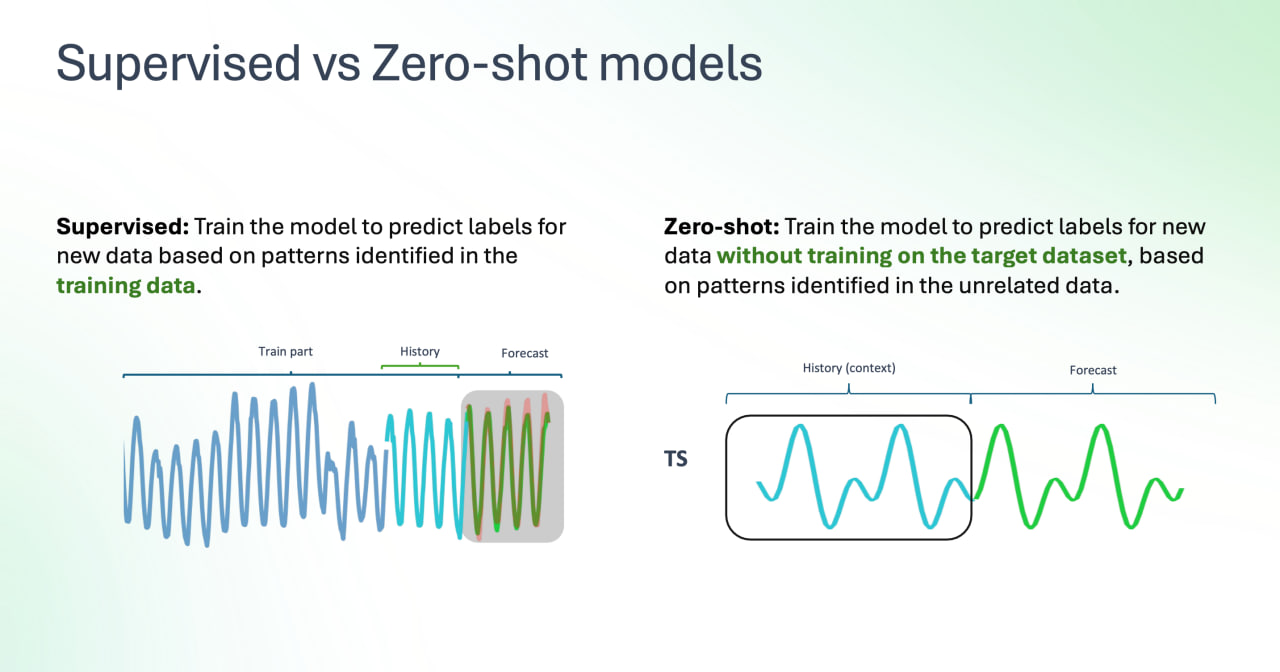

`Chronos` — это модель, которая использует предобученные трансформеры для предсказания временных рядов без дополнительной настройки.

Статья: https://arxiv.org/pdf/2403.07815

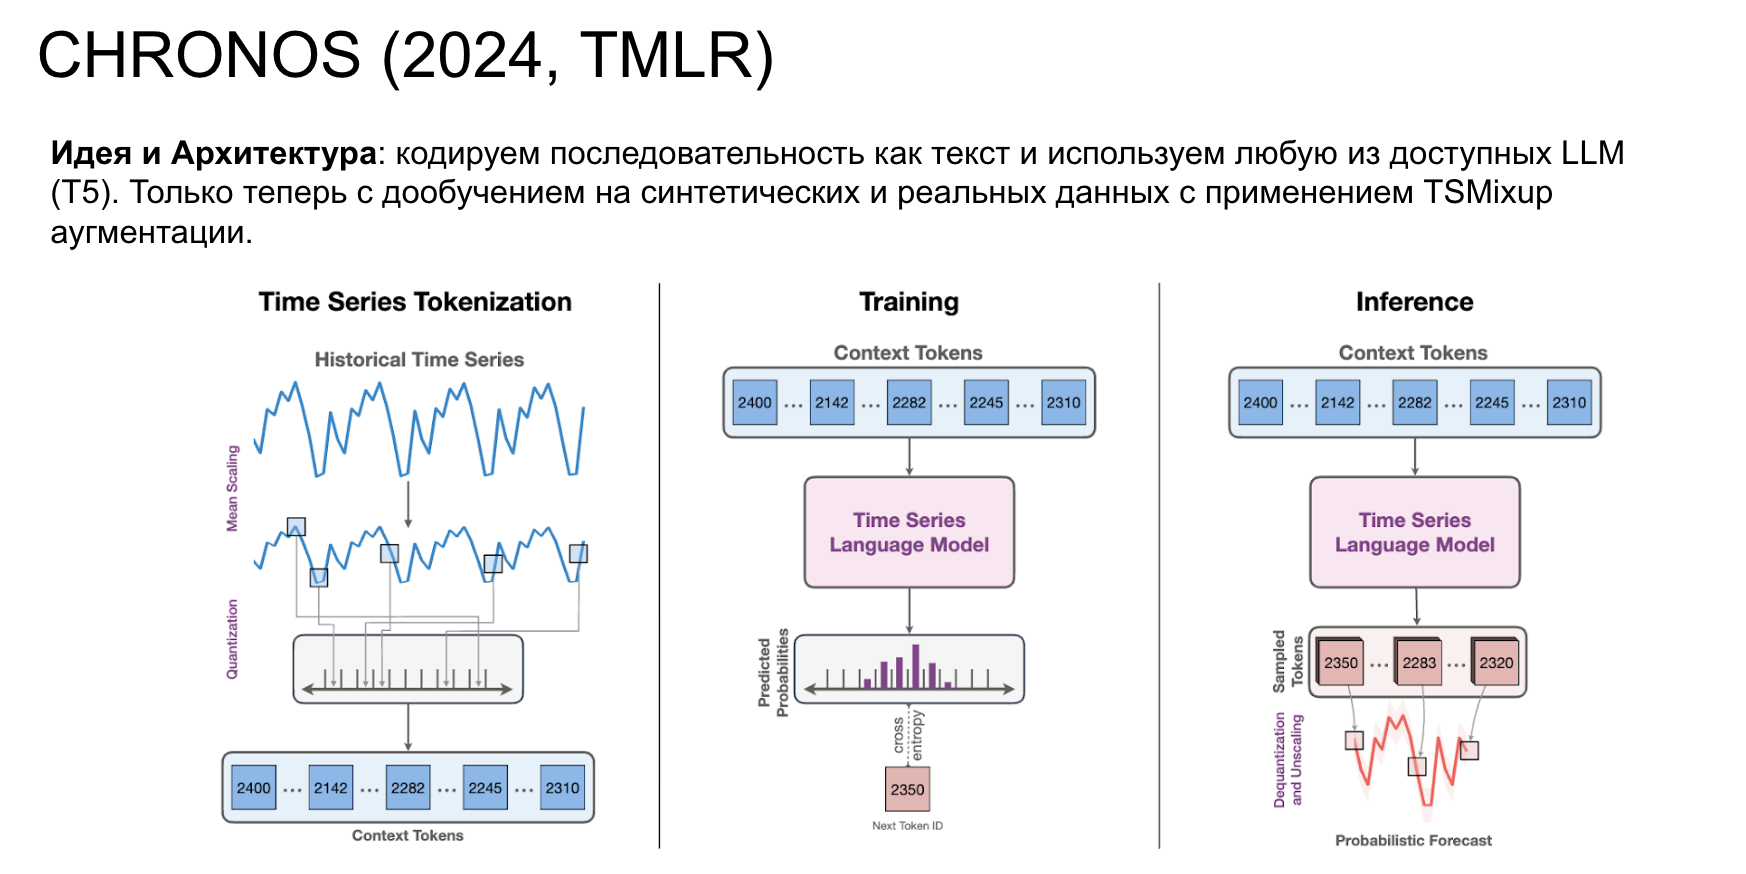

In [ ]:
seed_everything()
# Загрузим предобученную модель Chronos-Bolt
pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-small",
    device_map="cuda",
)

# Сделаем предсказание на тестовой выборке
test_preds = test_targets.copy()
test_preds.loc[:, 'value'] =  0

# Chronos — local модель, то есть на каждый ряд мы делаем предсказание отдельно
for current_id in tqdm(test_targets['id'].unique()):
    current_df = df[df["id"] == current_id]

    # В контекст передаем все точки, кроме последних HORIZON
    context = current_df.iloc[:-1 * HORIZON]

    pred = pipeline.predict(
        context=torch.tensor(context["value"].values.flatten().astype(float)),
        prediction_length=HORIZON
    ).numpy()[0,  :]
    # Chronos выдает распределение предсказаний, поэтому мы берем медиану
    # (можно использовать и другие статистики, например, какую-нибудь квантиль)
    pred = np.median(pred, axis=0)

    # Заполняем предсказания в тестовой выборке
    test_preds.loc[test_preds["id"] == current_id, 'value'] = pred

config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

  0%|          | 0/366 [00:00<?, ?it/s]

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


In [ ]:
analyze_predictions(train_df, test_targets, test_preds, last_points=50)

random 10 mae: 1405.1667781501346


__Что можно сказать про результаты zero-shot предсказаний? (помним, что модель вообще не обучалась на наших данных!)__